# Lab 3: Major Vote Classifier

In [1]:
import pandas as pd

## Heart Dataset

Load dataset

In [2]:
heart_tr = pd.read_csv("heart_train.tsv", sep = "\t")
heart_te = pd.read_csv("heart_test.tsv", sep = "\t")

In [3]:
heart_tr.head(3)

,sex,chest_pain,high_blood_sugar,abnormal_ecg,angina,flat_ST,fluoroscopy,thalassemia,heart_disease
0,0,0,0,1,1,0,1,1,1
1,1,1,0,0,0,0,1,1,1
2,1,0,0,1,1,1,0,1,1


In [4]:
heart_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   sex               200 non-null    int64
 1   chest_pain        200 non-null    int64
 2   high_blood_sugar  200 non-null    int64
 3   abnormal_ecg      200 non-null    int64
 4   angina            200 non-null    int64
 5   flat_ST           200 non-null    int64
 6   fluoroscopy       200 non-null    int64
 7   thalassemia       200 non-null    int64
 8   heart_disease     200 non-null    int64
dtypes: int64(9)
memory usage: 14.2 KB


In [5]:
heart_te.head(3)

,sex,chest_pain,high_blood_sugar,abnormal_ecg,angina,flat_ST,fluoroscopy,thalassemia,heart_disease
0,0,1,0,0,0,1,1,0,0
1,1,0,0,0,1,0,1,1,1
2,0,0,0,1,0,1,0,0,0


In [6]:
heart_te.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   sex               97 non-null     int64
 1   chest_pain        97 non-null     int64
 2   high_blood_sugar  97 non-null     int64
 3   abnormal_ecg      97 non-null     int64
 4   angina            97 non-null     int64
 5   flat_ST           97 non-null     int64
 6   fluoroscopy       97 non-null     int64
 7   thalassemia       97 non-null     int64
 8   heart_disease     97 non-null     int64
dtypes: int64(9)
memory usage: 6.9 KB


In [7]:
X_tr = heart_tr.drop("heart_disease", axis=1)
y_tr = heart_tr["heart_disease"]

X_te = heart_te.drop("heart_disease", axis=1)
y_te = heart_te["heart_disease"]

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

Classifiers

In [9]:
clfl = LogisticRegression(max_iter=200)
cldt = DecisionTreeClassifier(max_depth=5, random_state=42)
clknn = KNeighborsClassifier(n_neighbors=5)

In [10]:
vote_clf = VotingClassifier(estimators=[
    	("Logistic Regression", clfl),
        ("Decision Tree", cldt),
        ("KNN", clknn)],
    voting="hard")

Train

In [20]:
vote_clf.fit(X_tr, y_tr)

VotingClassifier(estimators=[('Logistic Regression',
                              LogisticRegression(max_iter=200)),
                             ('Decision Tree',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('KNN', KNeighborsClassifier())])

Evaluate

In [13]:
y_pred = vote_clf.predict(X_te)
y_pred

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1], dtype=int64)

In [14]:
print("Accuracy:", accuracy_score(y_te, y_pred))
print("Error:", 1 - accuracy_score(y_te, y_pred))

Accuracy: 0.7731958762886598
Error: 0.22680412371134018


Visualization

In [18]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

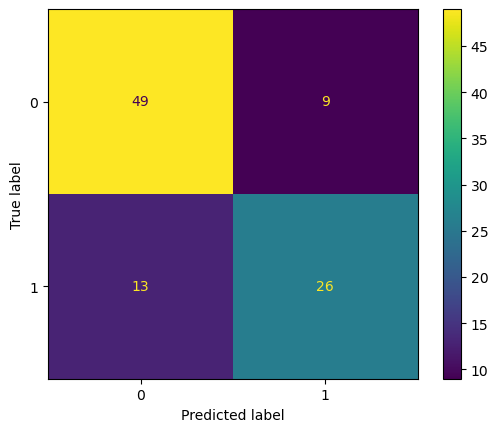

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [21]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
plt.show()

# Compare accuracies
for name, clf in [("Logistic Regression", clfl), ("Decision Tree", cldt), ("KNN", clknn), ('voter', vote_clf)]:
	print(name, accuracy_score(y_te, clf.predict(X_te)))
